# PDAC vs HCC PDE Output Comparison

Compares chemical concentration fields between:
- **PDAC** (our model): 50³ grid, steps 0–279, 600 s/step
- **HCC** (reference BioFVM): 50³ grid, steps 0–279, 600 s/step

Column name mapping:
| PDAC col | HCC col |
|----------|---------|
| O2       | O2      |
| IFN      | IFNg    |
| IL2      | IL_2    |
| IL10     | IL10    |
| TGFB     | TGFB    |
| CCL2     | CCL2    |
| ARGI     | ArgI    |
| NO       | NO      |
| IL12     | IL12    |
| VEGFA    | VEGFA   |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# ---------------------------------------------------------------------------
# Paths
# ---------------------------------------------------------------------------
PDAC_DIR = Path('../PDAC/sim/outputs/pde')
HCC_DIR  = Path('../PDAC/sim/HCC_outputs/snapShots')

# Column name map: PDAC → HCC
COL_MAP = {
    'O2':   'O2',
    'IFN':  'IFNg',
    'IL2':  'IL_2',
    'IL10': 'IL10',
    'TGFB': 'TGFB',
    'CCL2': 'CCL2',
    'ARGI': 'ArgI',
    'NO':   'NO',
    'IL12': 'IL12',
    'VEGFA':'VEGFA',
}
CHEMS  = list(COL_MAP.keys())
PRETTY = ['O₂', 'IFN-γ', 'IL-2', 'IL-10', 'TGF-β', 'CCL2', 'Arg-I', 'NO', 'IL-12', 'VEGF-A']

# Grid parameters (both grids are now 50³)
PDAC_N  = 50
HCC_N   = 50
DT_S    = 600.0   # seconds per step
N_STEPS = 280

print(f'PDAC files: {len(list(PDAC_DIR.glob("pde_step_*.csv")))}')
print(f'HCC  files: {len(list(HCC_DIR.glob("grid_core_*.csv")))}')

PDAC files: 280
HCC  files: 281


In [2]:
# ---------------------------------------------------------------------------
# Loader helpers
# ---------------------------------------------------------------------------

def load_pdac(step: int) -> pd.DataFrame:
    path = PDAC_DIR / f'pde_step_{step:06d}.csv'
    return pd.read_csv(path)

def load_hcc(step: int) -> pd.DataFrame:
    path = HCC_DIR / f'grid_core_{step}.csv'
    df = pd.read_csv(path)
    # Rename HCC cols → PDAC canonical names
    rev = {v: k for k, v in COL_MAP.items()}
    return df.rename(columns=rev)

def radial_profile(df: pd.DataFrame, chem: str, grid_n: int) -> pd.DataFrame:
    """Compute mean concentration vs radial distance from grid center."""
    cx = cy = cz = (grid_n - 1) / 2.0
    r = np.sqrt((df.x - cx)**2 + (df.y - cy)**2 + (df.z - cz)**2)
    tmp = pd.DataFrame({'r': r, 'c': df[chem]})
    # Bin by integer distance
    tmp['r_bin'] = np.round(r).astype(int)
    return tmp.groupby('r_bin')['c'].mean().reset_index().rename(columns={'r_bin':'r','c':chem})

# Quick sanity check
df0_pdac = load_pdac(0)
df0_hcc  = load_hcc(0)
print('PDAC step 0 shape:', df0_pdac.shape, '  cols:', list(df0_pdac.columns))
print('HCC  step 0 shape:', df0_hcc.shape,  '  cols:', list(df0_hcc.columns))

PDAC step 0 shape: (125000, 13)   cols: ['x', 'y', 'z', 'O2', 'IFN', 'IL2', 'IL10', 'TGFB', 'CCL2', 'ARGI', 'NO', 'IL12', 'VEGFA']
HCC  step 0 shape: (125000, 13)   cols: ['x', 'y', 'z', 'IFN', 'IL2', 'CCL2', 'ARGI', 'NO', 'TGFB', 'IL10', 'IL12', 'VEGFA', 'O2']


In [3]:
# ---------------------------------------------------------------------------
# 1. Bulk statistics over time (mean, max)
# ---------------------------------------------------------------------------
steps = list(range(0, N_STEPS, 5))   # every 5 steps
times_h = [s * DT_S / 3600.0 for s in steps]

stats_pdac = {c: {'mean': [], 'max': []} for c in CHEMS}
stats_hcc  = {c: {'mean': [], 'max': []} for c in CHEMS}

print('Computing bulk stats...', end='')
for s in steps:
    dp = load_pdac(s)
    dh = load_hcc(s)
    for c in CHEMS:
        stats_pdac[c]['mean'].append(dp[c].mean())
        stats_pdac[c]['max'].append(dp[c].max())
        stats_hcc[c]['mean'].append(dh[c].mean())
        stats_hcc[c]['max'].append(dh[c].max())
print(' done')

Computing bulk stats...

 done


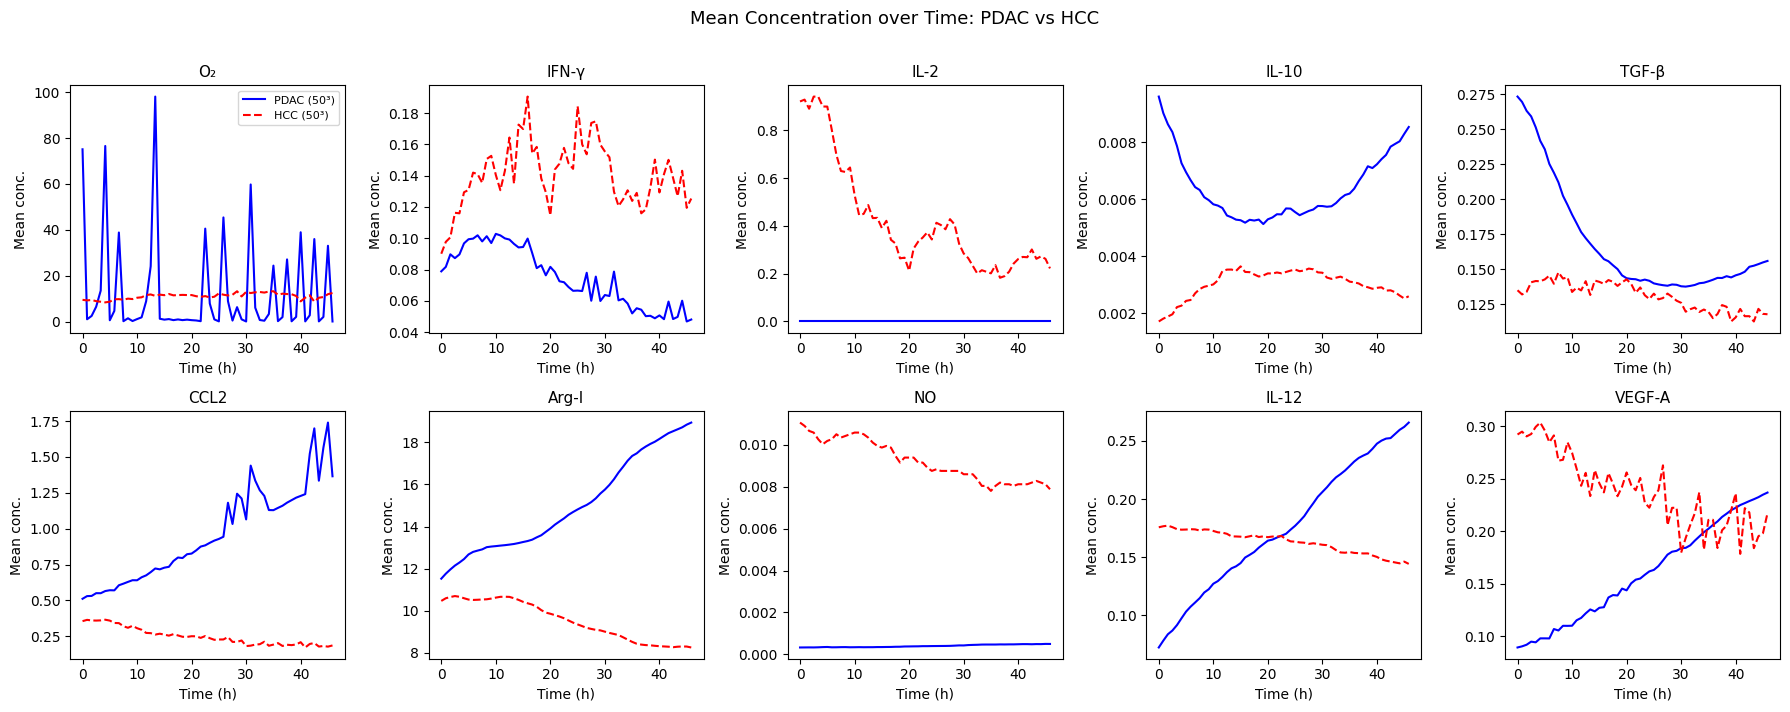

Saved pde_comparison_mean_over_time.png


In [4]:
# ---------------------------------------------------------------------------
# Plot: mean concentration over time — all chemicals
# ---------------------------------------------------------------------------
ncols = 5
nrows = 2
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 7))
axes = axes.flatten()

for i, (chem, label) in enumerate(zip(CHEMS, PRETTY)):
    ax = axes[i]
    ax.plot(times_h, stats_pdac[chem]['mean'], 'b-',  lw=1.5, label='PDAC (50³)')
    ax.plot(times_h, stats_hcc[chem]['mean'],  'r--', lw=1.5, label='HCC (50³)')
    ax.set_title(label, fontsize=11)
    ax.set_xlabel('Time (h)')
    ax.set_ylabel('Mean conc.')
    if i == 0:
        ax.legend(fontsize=8)

fig.suptitle('Mean Concentration over Time: PDAC vs HCC', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('pde_comparison_mean_over_time.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved pde_comparison_mean_over_time.png')

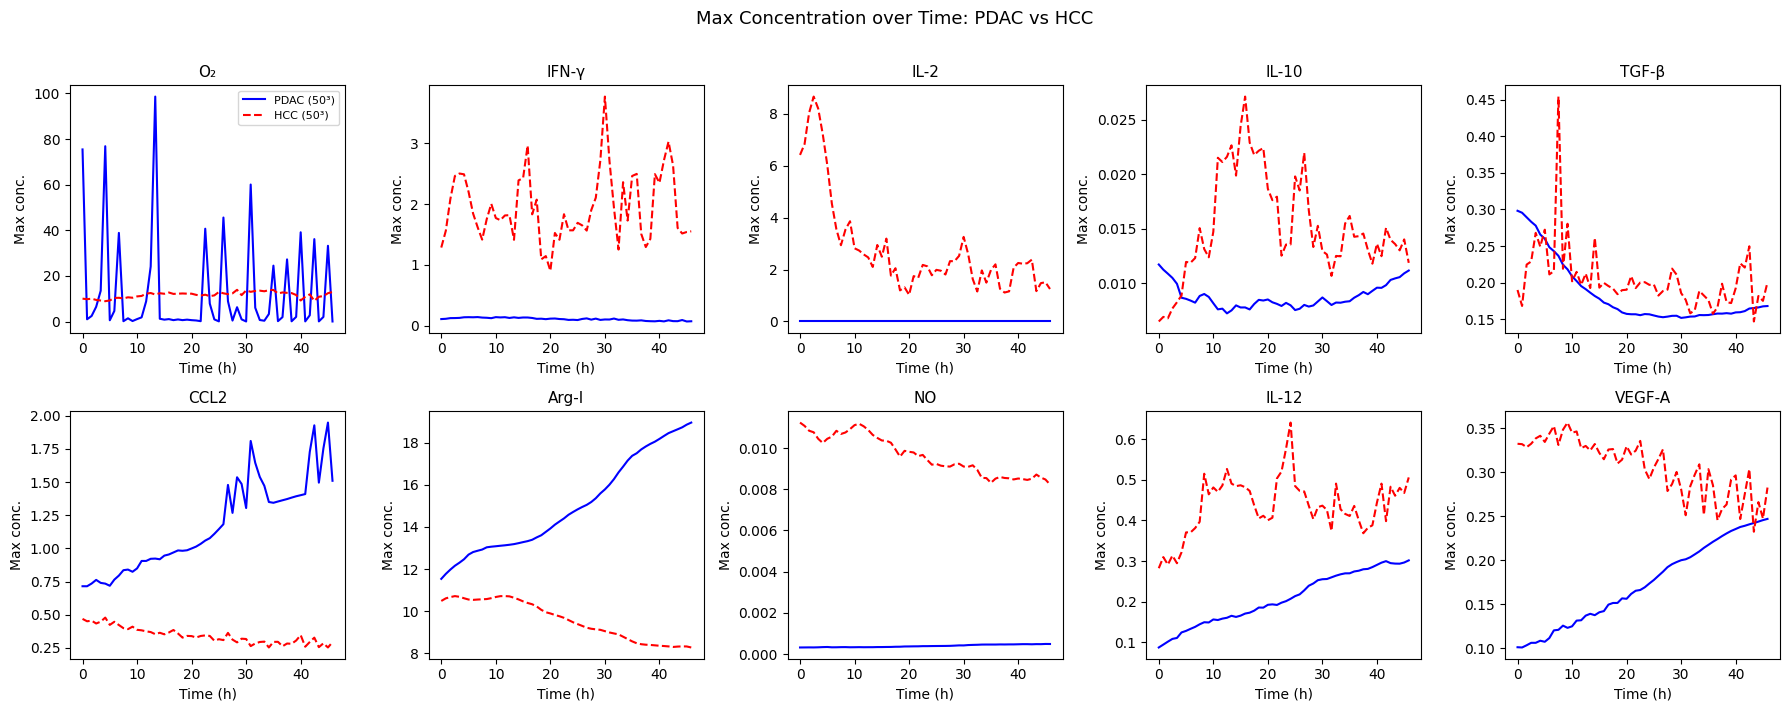

Saved pde_comparison_max_over_time.png


In [5]:
# ---------------------------------------------------------------------------
# Plot: max concentration over time — all chemicals
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 7))
axes = axes.flatten()

for i, (chem, label) in enumerate(zip(CHEMS, PRETTY)):
    ax = axes[i]
    ax.plot(times_h, stats_pdac[chem]['max'], 'b-',  lw=1.5, label='PDAC (50³)')
    ax.plot(times_h, stats_hcc[chem]['max'],  'r--', lw=1.5, label='HCC (50³)')
    ax.set_title(label, fontsize=11)
    ax.set_xlabel('Time (h)')
    ax.set_ylabel('Max conc.')
    if i == 0:
        ax.legend(fontsize=8)

fig.suptitle('Max Concentration over Time: PDAC vs HCC', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('pde_comparison_max_over_time.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved pde_comparison_max_over_time.png')

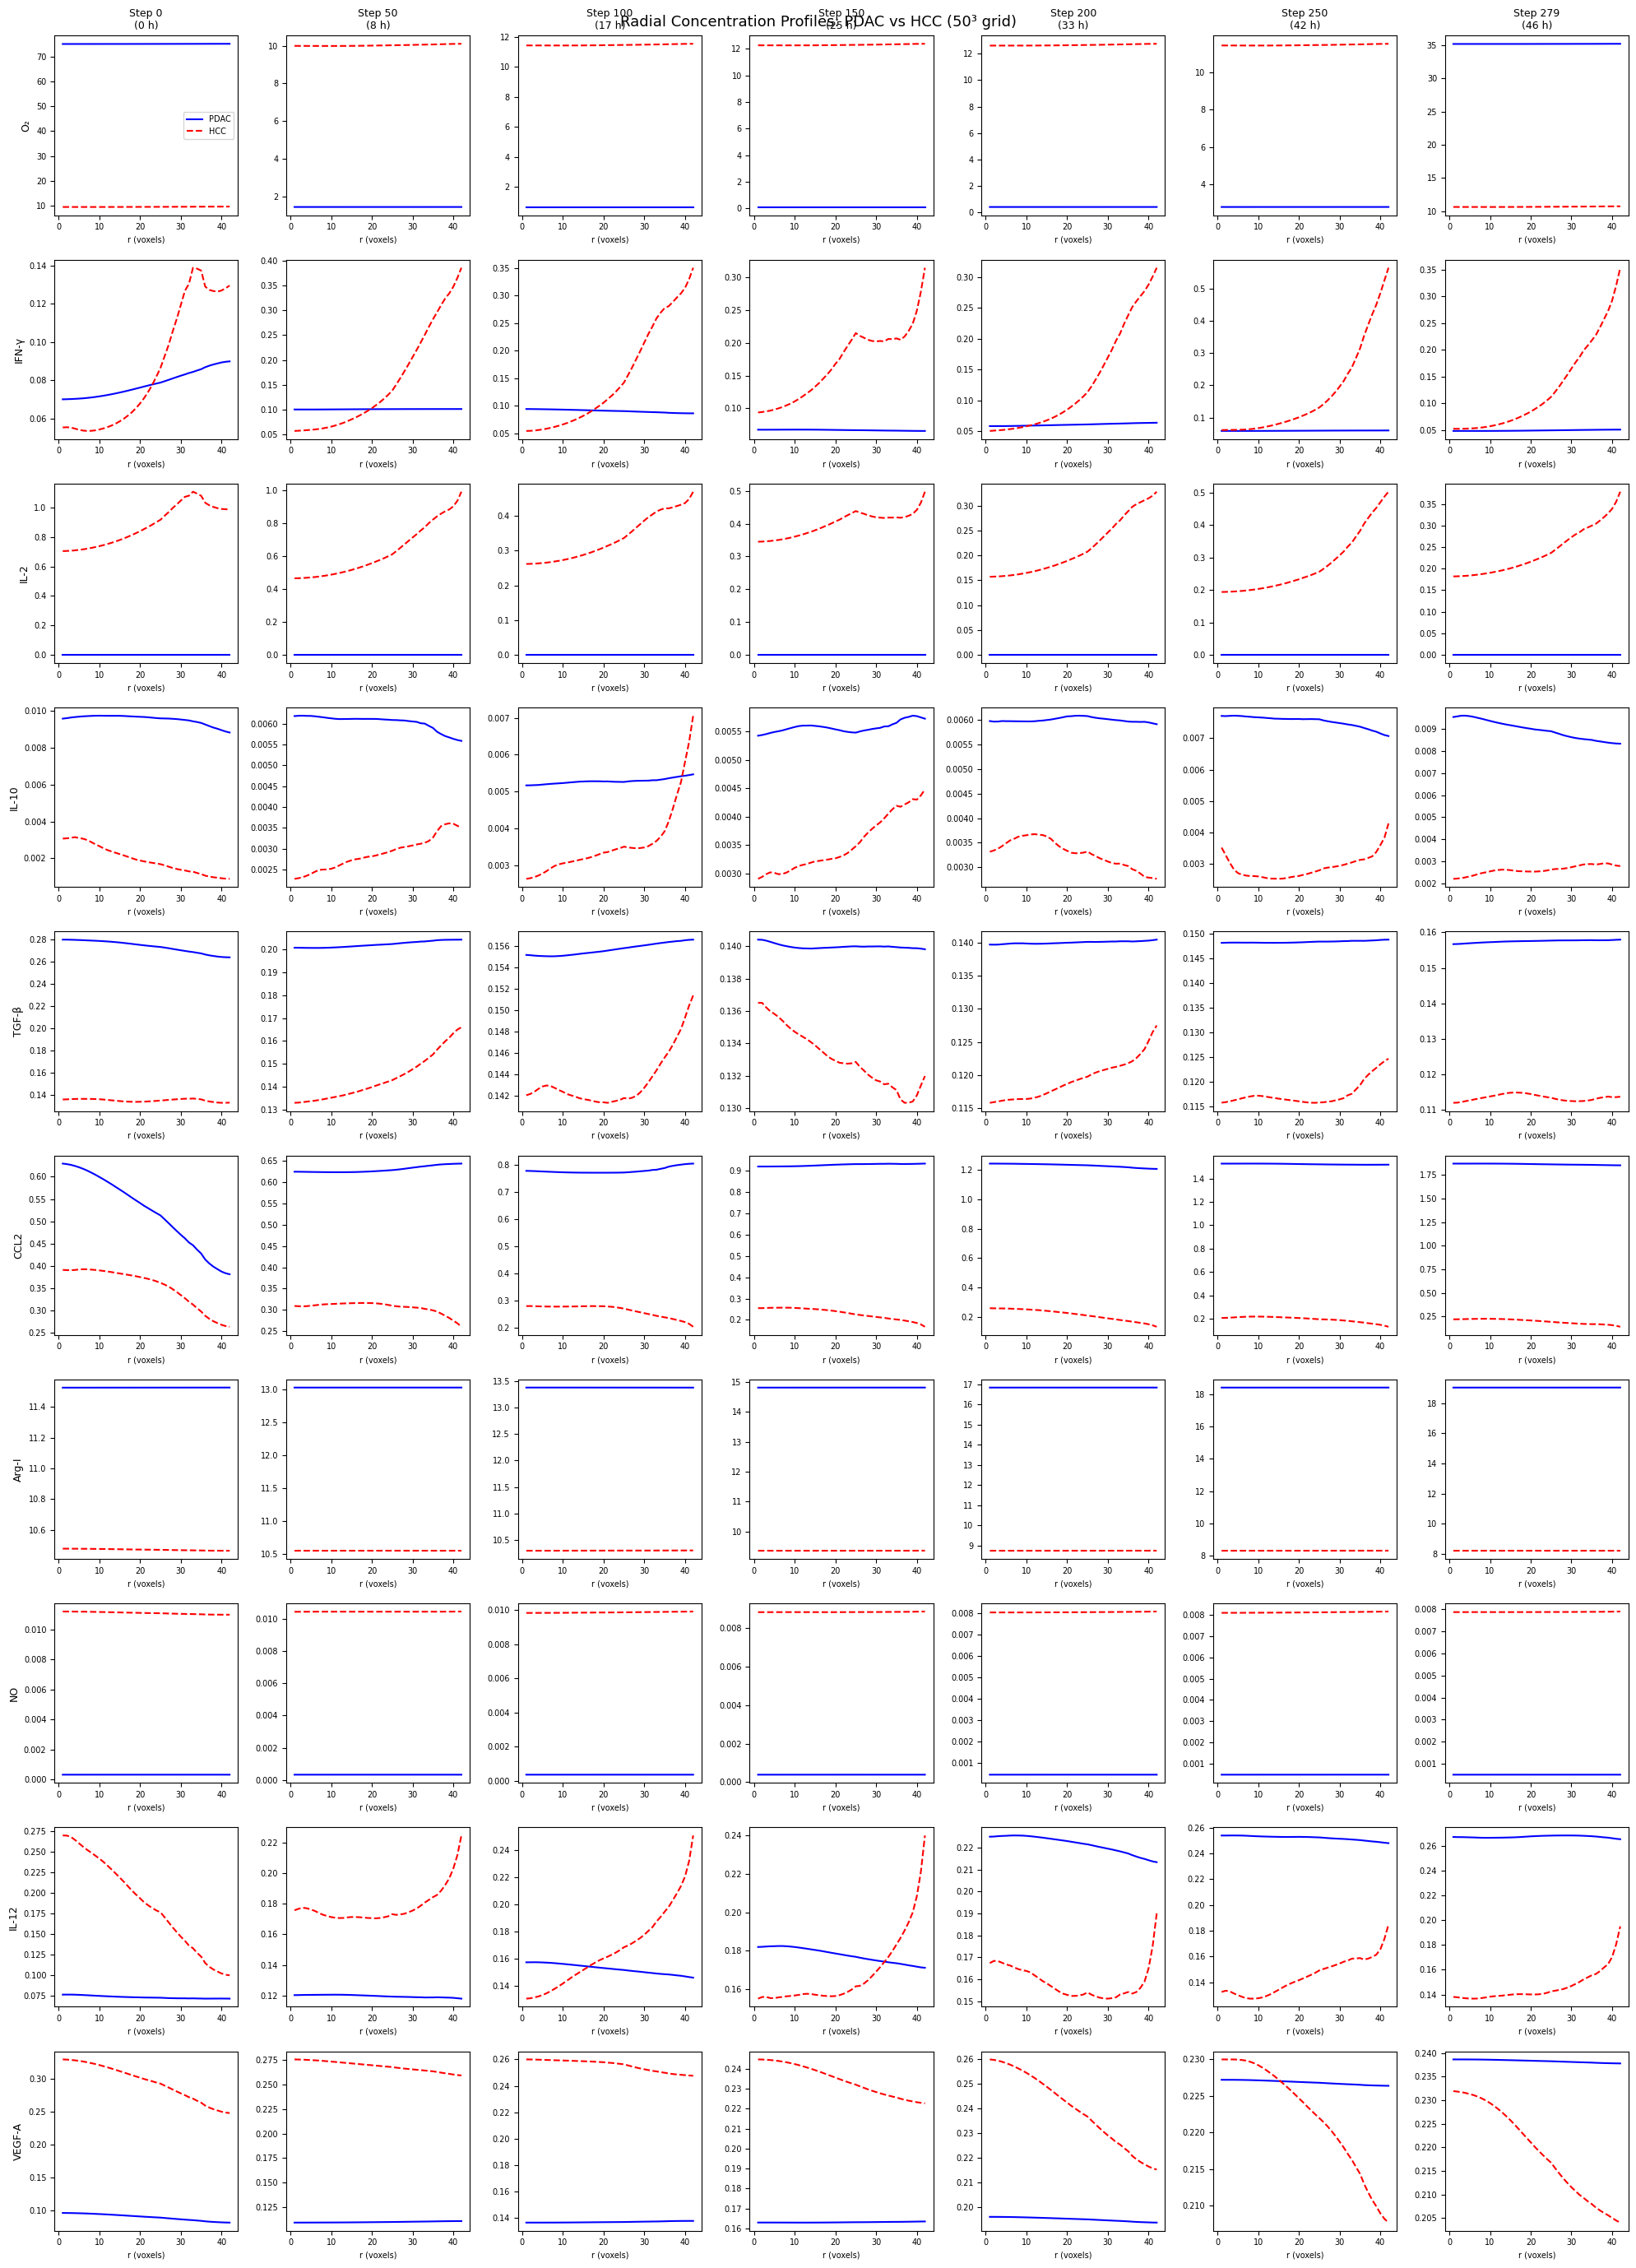

Saved pde_comparison_radial_profiles.png


In [6]:
# ---------------------------------------------------------------------------
# 2. Radial profiles at selected steps
# ---------------------------------------------------------------------------
SNAP_STEPS = [0, 50, 100, 150, 200, 250, 279]

fig, axes = plt.subplots(len(CHEMS), len(SNAP_STEPS), figsize=(20, 28))

for row, (chem, label) in enumerate(zip(CHEMS, PRETTY)):
    for col, step in enumerate(SNAP_STEPS):
        ax = axes[row, col]
        dp = load_pdac(step)
        dh = load_hcc(step)
        rp = radial_profile(dp, chem, PDAC_N)
        rh = radial_profile(dh, chem, HCC_N)
        # Both grids are 50³ so no normalization needed — plot raw voxel distance
        ax.plot(rp.r, rp[chem], 'b-',  lw=1.5)
        ax.plot(rh.r, rh[chem], 'r--', lw=1.5)
        if row == 0:
            ax.set_title(f'Step {step}\n({step*DT_S/3600:.0f} h)', fontsize=9)
        if col == 0:
            ax.set_ylabel(label, fontsize=9)
        ax.tick_params(labelsize=7)
        ax.set_xlabel('r (voxels)', fontsize=7)

from matplotlib.lines import Line2D
legend_els = [Line2D([0],[0],color='b',lw=1.5,label='PDAC'),
              Line2D([0],[0],color='r',lw=1.5,ls='--',label='HCC')]
axes[0,0].legend(handles=legend_els, fontsize=7)

fig.suptitle('Radial Concentration Profiles: PDAC vs HCC (50³ grid)', fontsize=13)
plt.tight_layout()
plt.savefig('pde_comparison_radial_profiles.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved pde_comparison_radial_profiles.png')

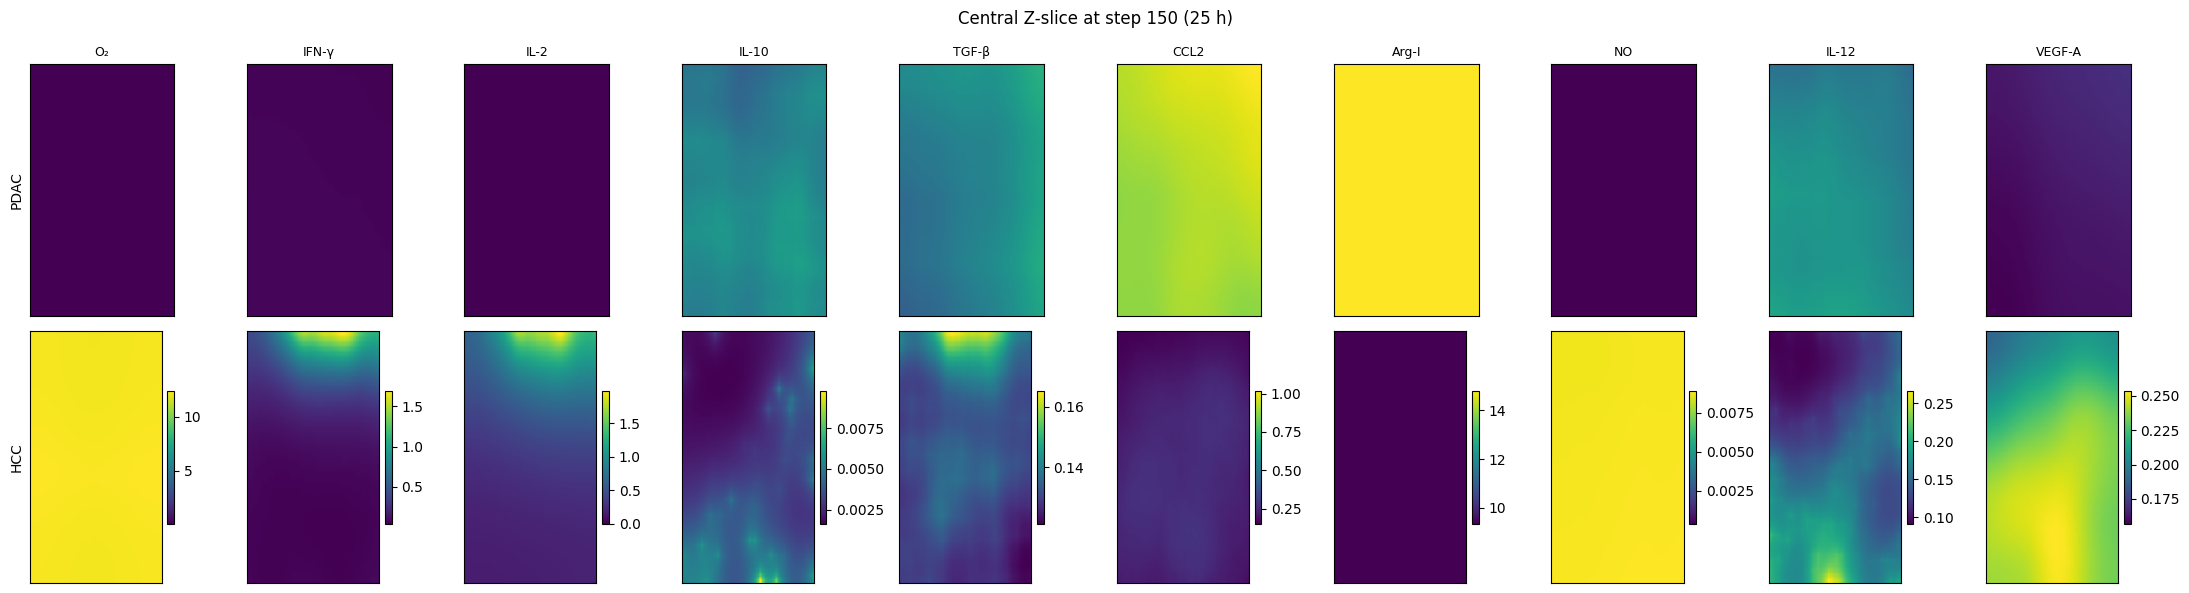

Saved pde_comparison_zslice_step150.png


In [7]:
# ---------------------------------------------------------------------------
# 3. Central Z-slice comparison at a single step
# ---------------------------------------------------------------------------
COMPARE_STEP = 150

def slice_at_z(df: pd.DataFrame, grid_n: int, chem: str) -> np.ndarray:
    """Extract central z-slice as 2D array."""
    cz = grid_n // 2
    sl = df[df.z == cz].copy()
    arr = np.full((grid_n, grid_n), np.nan)
    for _, row in sl.iterrows():
        arr[int(row.y), int(row.x)] = row[chem]
    return arr

dp = load_pdac(COMPARE_STEP)
dh = load_hcc(COMPARE_STEP)

fig, axes = plt.subplots(2, len(CHEMS), figsize=(22, 6))

for col, (chem, label) in enumerate(zip(CHEMS, PRETTY)):
    sp = slice_at_z(dp, PDAC_N, chem)
    sh = slice_at_z(dh, HCC_N, chem)
    vmin = min(np.nanmin(sp), np.nanmin(sh))
    vmax = max(np.nanmax(sp), np.nanmax(sh))
    kw = dict(vmin=vmin, vmax=vmax, cmap='viridis', aspect='auto')

    im0 = axes[0, col].imshow(sp, **kw, origin='lower')
    im1 = axes[1, col].imshow(sh, **kw, origin='lower')

    axes[0, col].set_title(label, fontsize=9)
    axes[0, col].set_xticks([]); axes[0, col].set_yticks([])
    axes[1, col].set_xticks([]); axes[1, col].set_yticks([])
    plt.colorbar(im1, ax=axes[1,col], fraction=0.046, pad=0.04)

axes[0, 0].set_ylabel('PDAC', fontsize=10)
axes[1, 0].set_ylabel('HCC', fontsize=10)

fig.suptitle(f'Central Z-slice at step {COMPARE_STEP} ({COMPARE_STEP*DT_S/3600:.0f} h)', fontsize=12)
plt.tight_layout()
plt.savefig(f'pde_comparison_zslice_step{COMPARE_STEP}.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Saved pde_comparison_zslice_step{COMPARE_STEP}.png')

In [8]:
# ---------------------------------------------------------------------------
# 4. Ratio summary table: PDAC_mean / HCC_mean at final step
# ---------------------------------------------------------------------------
FINAL = 279
dp_f = load_pdac(FINAL)
dh_f = load_hcc(FINAL)

rows = []
for chem, label in zip(CHEMS, PRETTY):
    pm = dp_f[chem].mean()
    hm = dh_f[chem].mean()
    px = dp_f[chem].max()
    hx = dh_f[chem].max()
    ratio = pm / hm if hm != 0 else float('nan')
    rows.append({'Chemical': label,
                 'PDAC mean': f'{pm:.4g}',
                 'HCC mean':  f'{hm:.4g}',
                 'Ratio P/H': f'{ratio:.3f}',
                 'PDAC max':  f'{px:.4g}',
                 'HCC max':   f'{hx:.4g}'})

summary = pd.DataFrame(rows)
print(f'\n=== Comparison at step {FINAL} ({FINAL*DT_S/3600:.0f} h) ===')
print(summary.to_string(index=False))


=== Comparison at step 279 (46 h) ===
Chemical PDAC mean HCC mean Ratio P/H  PDAC max  HCC max
      O₂     35.22    10.65     3.308     35.39     11.1
   IFN-γ   0.04964   0.1216     0.408   0.07144    1.464
    IL-2         0   0.2405     0.000         0    1.533
   IL-10  0.008867 0.002645     3.353   0.01187   0.0117
   TGF-β    0.1576   0.1135     1.388    0.1695   0.1624
    CCL2     1.863   0.1956     9.523     2.066   0.2925
   Arg-I     19.04    8.221     2.316     19.05    8.247
      NO 0.0005015 0.007883     0.064 0.0005032 0.008246
   IL-12    0.2678   0.1438     1.863    0.3042    0.447
  VEGF-A    0.2383   0.2173     1.096     0.248   0.2939


In [9]:
# ---------------------------------------------------------------------------
# 5. Steady-state check: are concentrations still changing at step 279?
# ---------------------------------------------------------------------------
LAST = 279
PREV = 270
dp_last = load_pdac(LAST)
dp_prev = load_pdac(PREV)
dh_last = load_hcc(LAST)
dh_prev = load_hcc(PREV)

print(f'Relative change between step {PREV} and {LAST} (|Δ|/mean):')
print(f'{"Chemical":<10} {"PDAC":<12} {"HCC":<12}')
print('-' * 36)
for chem, label in zip(CHEMS, PRETTY):
    delta_p = abs(dp_last[chem].mean() - dp_prev[chem].mean())
    delta_h = abs(dh_last[chem].mean() - dh_prev[chem].mean())
    mean_p  = dp_last[chem].mean()
    mean_h  = dh_last[chem].mean()
    rel_p = delta_p / mean_p if mean_p > 0 else 0
    rel_h = delta_h / mean_h if mean_h > 0 else 0
    print(f'{label:<10} {rel_p:<12.4f} {rel_h:<12.4f}')

Relative change between step 270 and 279 (|Δ|/mean):
Chemical   PDAC         HCC         
------------------------------------
O₂         0.0613       0.1236      
IFN-γ      0.0577       0.0179      
IL-2       0.0000       0.0903      
IL-10      0.0652       0.0455      
TGF-β      0.0170       0.0410      
CCL2       0.0663       0.0873      
Arg-I      0.0106       0.0101      
NO         0.0158       0.0303      
IL-12      0.0212       0.0164      
VEGF-A     0.0144       0.0882      
